

---

### 📌 **Why Handle Outliers?**
Outliers can:
- Skew data distributions
- Impact model performance (especially in linear and distance-based algorithms)
- Lead to misleading statistical summaries

Hence, **handling outliers is a critical part of preprocessing**.

---

### 📊 **Overview of Techniques**

| Method               | Description | Keeps Data? | Suitable For        |
|----------------------|-------------|-------------|----------------------|
| Winsorization        | Replaces outliers with percentile bounds | ✅ Yes | When you don't want to lose data |
| Clipping             | Caps values at fixed min/max | ✅ Yes | When bounds are known |
| Z-Score Filtering    | Removes values with z-score > threshold | ❌ No | Normal distributions |
| IQR Method           | Filters values outside Q1 - 1.5*IQR and Q3 + 1.5*IQR | ❌ No | Skewed distributions |
| Log / Box-Cox        | Reduces skew, transforms scale | ✅ Yes | Positively skewed data |
| Robust Scaler        | Scales using median and IQR | ✅ Yes | Scaling for outlier-resilient models |

---

## 🔧 **Step-by-Step Code with Explanation**

We'll work with a synthetic dataset.

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create data with outliers
np.random.seed(0)
normal_data = np.random.normal(loc=50, scale=5, size=100)
outliers = np.random.normal(loc=100, scale=1, size=5)
data = np.concatenate((normal_data, outliers))

df = pd.DataFrame(data, columns=['value'])
sns.boxplot(x=df['value'])
plt.title("Original Data with Outliers")
plt.show()
```

---

### 1️⃣ **Winsorization**

```python
from scipy.stats.mstats import winsorize

# 5% Winsorization
df['winsorized'] = winsorize(df['value'], limits=[0.05, 0.05])
sns.boxplot(x=df['winsorized'])
plt.title("Winsorized Data")
plt.show()
```

✔ Keeps data  
✔ Useful when data is precious

---

### 2️⃣ **Z-Score Method**

```python
from scipy.stats import zscore

z_scores = zscore(df['value'])
df_z_filtered = df[np.abs(z_scores) < 3]
sns.boxplot(x=df_z_filtered['value'])
plt.title("Z-Score Filtered Data")
plt.show()
```

✔ Simple  
✘ May remove important edge cases

---

### 3️⃣ **IQR Method**

```python
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_iqr_filtered = df[(df['value'] >= lower_bound) & (df['value'] <= upper_bound)]
sns.boxplot(x=df_iqr_filtered['value'])
plt.title("IQR Filtered Data")
plt.show()
```

✔ More robust for skewed data  
✘ Removes rows

---

### 4️⃣ **Clipping**

```python
# Manually define bounds
lower_clip, upper_clip = 40, 60
df['clipped'] = df['value'].clip(lower=lower_clip, upper=upper_clip)
sns.boxplot(x=df['clipped'])
plt.title("Clipped Data")
plt.show()
```

✔ Good when business rules exist  
✘ Not data-driven

---

### 5️⃣ **Robust Scaler**

```python
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df['scaled'] = scaler.fit_transform(df[['value']])
sns.histplot(df['scaled'], kde=True)
plt.title("Robust Scaled Data")
plt.show()
```

✔ Best when you want to keep all values  
✔ Maintains relative scale  
✘ Only normalizes, doesn’t remove/replace outliers

---

### ✅ **Key Takeaways**

- Start with **EDA (Exploratory Data Analysis)** → Use boxplots, histograms.
- **Winsorization** is preferred when keeping data is important.
- Use **IQR or Z-score** when removing extreme values is okay.
- Apply **RobustScaler** when you're scaling input for models like Logistic Regression, SVM, etc.
- Always **evaluate model performance** before and after preprocessing.

---

### 💡 **Tips from Experience**
- Always **visualize the impact** of preprocessing.
- Never blindly remove outliers—**understand their origin** first (could be fraud, anomaly, or genuine signal).
- Maintain a **data preprocessing pipeline** for reproducibility.

---



Step 1: Original Data with Outliers


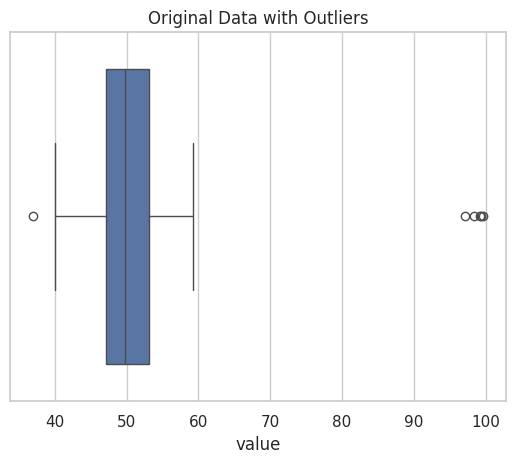

Step 2: Winsorized Data


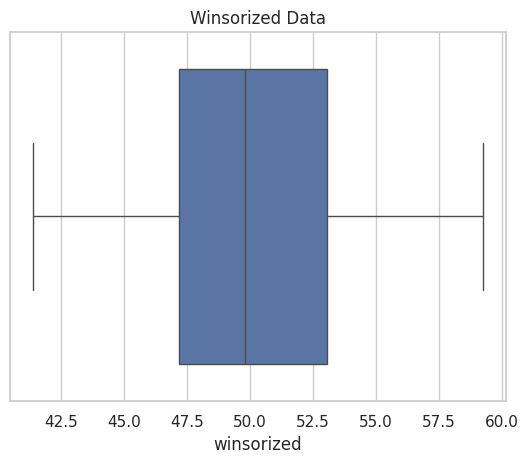

Step 3: Z-Score Filtered Data


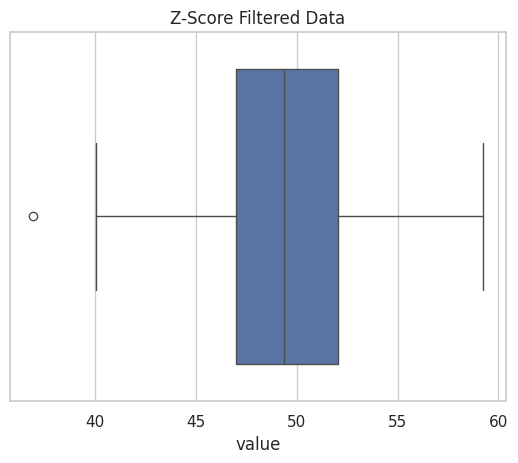

Step 4: IQR Filtered Data


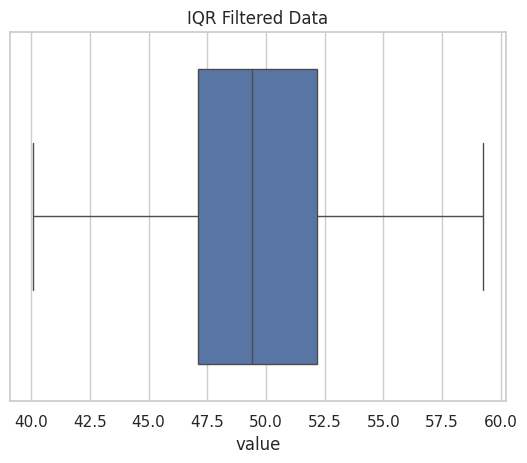

Step 5: Clipped Data


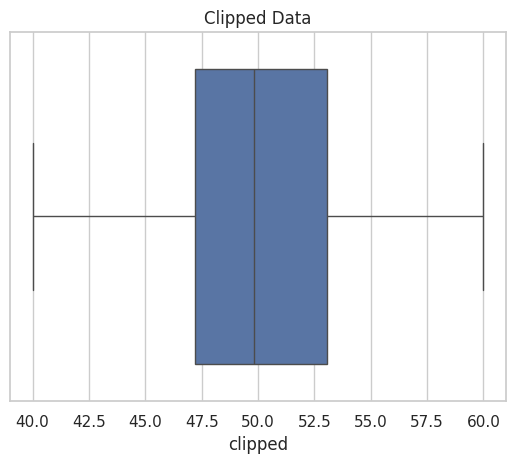

Step 6: Robust Scaled Data


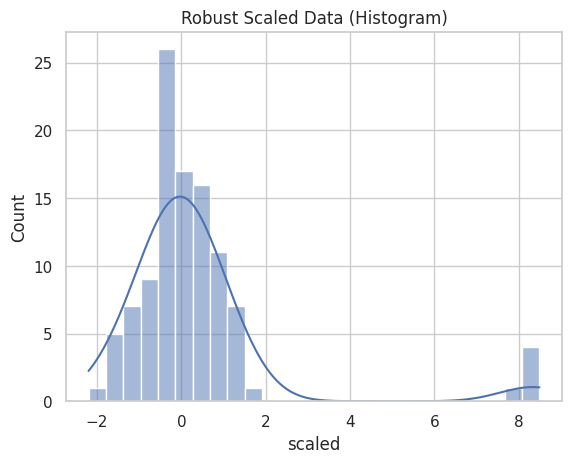

In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import RobustScaler

# Set plot style
sns.set(style="whitegrid")

# Step 1: Generate synthetic dataset with outliers
np.random.seed(42)
normal_data = np.random.normal(loc=50, scale=5, size=100)
outliers = np.random.normal(loc=100, scale=2, size=5)
data = np.concatenate((normal_data, outliers))
df = pd.DataFrame(data, columns=['value'])

# Helper function to plot boxplots
def plot_box(title, col='value'):
    sns.boxplot(x=df[col])
    plt.title(title)
    plt.show()

print("Step 1: Original Data with Outliers")
plot_box("Original Data with Outliers")

# Step 2: Winsorization
df['winsorized'] = winsorize(df['value'], limits=[0.05, 0.05])
print("Step 2: Winsorized Data")
plot_box("Winsorized Data", col='winsorized')

# Step 3: Z-Score Filtering (new DataFrame to avoid NaNs)
z_scores = zscore(df['value'])
df_z_filtered = df[np.abs(z_scores) < 3]
print("Step 3: Z-Score Filtered Data")
sns.boxplot(x=df_z_filtered['value'])
plt.title("Z-Score Filtered Data")
plt.show()

# Step 4: IQR Filtering
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_iqr_filtered = df[(df['value'] >= lower) & (df['value'] <= upper)]

print("Step 4: IQR Filtered Data")
sns.boxplot(x=df_iqr_filtered['value'])
plt.title("IQR Filtered Data")
plt.show()

# Step 5: Clipping
df['clipped'] = df['value'].clip(lower=40, upper=60)
print("Step 5: Clipped Data")
plot_box("Clipped Data", col='clipped')

# Step 6: Robust Scaler
scaler = RobustScaler()
df['scaled'] = scaler.fit_transform(df[['value']])
print("Step 6: Robust Scaled Data")
sns.histplot(df['scaled'], kde=True)
plt.title("Robust Scaled Data (Histogram)")
plt.show()
